In [1]:
import pandas as pd
from urllib.parse import urlparse
import matplotlib.pyplot as plt
import re
from urllib.parse import urlparse
from collections import Counter
import math

#### Read one benign dataset

In [2]:
# Load the benign URLs
benign_df = pd.read_csv("datasets/benign_dataframe_0.csv")  
print(f"Number of benign URLs: {len(benign_df)}")
benign_df.sample(3)

Number of benign URLs: 1000


,id,url,html
916,0bb8ae9a-6b13-4061-b13e-59b4f1553374,https://economipedia.com/,PGh0bWwgbGFuZz0iZXMiIGRhdGEtc2Nyb2xsPSIwIj48aG...
661,085fdaa9-667b-493d-a598-dc6413cfeecc,https://www.ronet.de/,PGh0bWwgbGFuZz0iZGUiIGNsYXNzPSJqcyI+PGhlYWQ+Cg...
436,05956621-ea27-47b2-aa80-e7a040eda203,https://sleepdoctor.com/,PGh0bWwgY2xhc3M9Im5vLWpzIG5vLXN2ZyBwYWdlIiBsYW...


## Real-world dataset

#### Convert the index.sql to CSV
- https://data.mendeley.com/datasets/n96ncsr5g4/1

In [3]:
import re
import pandas as pd

# Set path to your .sql dump file
sql_path = "/home/devel/temp/school/cyber/cyber_ai_course_runi/datasets/mendeley/index.sql"  # Replace with your actual file path

# Read file contents
with open(sql_path, "r", encoding="utf-8") as f:
    content = f.read()

# Match all (rec_id, 'url', 'website', result, 'created_date') sets
pattern = re.findall(r"\((\d+),\s*'([^']+)',\s*'[^']*',\s*(\d),\s*'[^']*'\)", content)

# Build dataframe
df = pd.DataFrame(pattern, columns=["rec_id", "url", "label"])
df["rec_id"] = df["rec_id"].astype(int)
df["label"] = df["label"].astype(int)

# Save to CSV
df.to_csv("phishing_dataset_mendeley.csv", index=False)
print("✅ Extracted", len(df), "records to phishing_dataset.csv")
df.sample(3)

✅ Extracted 79987 records to phishing_dataset.csv


,rec_id,url,label
57295,57303,https://doccomo.ne.uqzv.xyz,1
74601,74613,https://casascamijanes.com/vendor-portal/remit...,1
2256,2257,http://estocap.com.br/wordpress/wp-includes/js...,1


In [4]:
df = pd.read_csv("datasets/mendeley/train_urls.csv")

### Get a simple heuristic for URL based detection:

In [5]:
def entropy(s):
    probs = [freq / len(s) for freq in Counter(s).values()]
    return -sum(p * math.log2(p) for p in probs)

def is_phishing_url(url):
    try:
        parsed = urlparse(url)
        hostname = parsed.hostname or ""
        tld = hostname.split('.')[-1]
        score = 0

        subdomain = '.'.join(hostname.split('.')[:-2]) if len(hostname.split('.')) >= 3 else ''
        # Check if the subdomain length is greater than 5
        if len(subdomain) > 5:
            score += 0.2

        # Check if the hostname contains free hosting keywords
        if any(fh in hostname for fh in ["weebly", "netlify", "000webhost", "github"]):
            score += 0.3

        # Check if the hostname contains hyphens
        if hostname.count('-') >= 1:
            score += 0.1

        # Check if the top-level domain is suspicious
        if tld in ["tk", "ml", "ga", "cf", "gq"]:
            score += 0.2

        # Check if the URL contains phishing-related keywords
        if any(k in url.lower() for k in ["login", "verify", "account", "secure", "update", "bank"]):
            score += 0.2

        # Check if the URL length is greater than 75
        if len(url) > 75:
            score += 0.1

        # Check if the hostname contains more than 4 digits
        digit_count = sum(c.isdigit() for c in hostname)
        if digit_count > 4:
            score += 0.1

        # Check if the entropy of the hostname is high
        host_entropy = entropy(hostname)
        # A higher entropy value indicates more randomness
        # and less predictability, which is often a sign of phishing
        # A threshold of 4.3 is chosen based on empirical analysis
        # of the dataset, but this can be adjusted based on specific needs
        # and characteristics of the data.
        if host_entropy > 4.3:
            score += 0.1

        # Check if the hostname is an IP address
        if re.match(r'^\d{1,3}(\.\d{1,3}){3}$', hostname):
            score += 0.2

        # Check if the URL contains special characters
        if any(c in url for c in ['%', '@', '&', '$']):
            score += 0.1

        return min(score, 1.0)

    except:
        return 0.0


### Check the heuiristic based detector on the benign and real-world datasets:

#### Benign Dataset

Avg score: 0.0242
Number flagged as phishing: 0


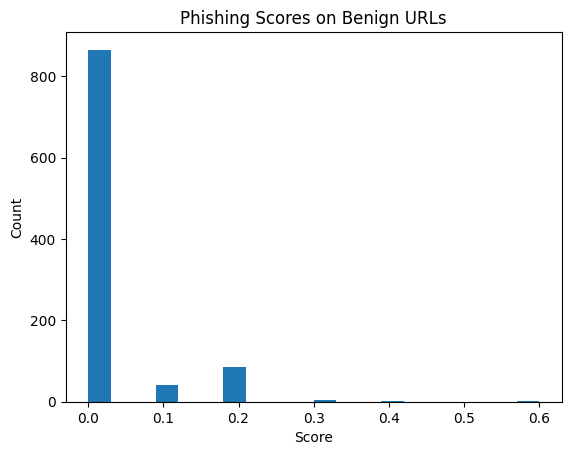

In [ ]:
# Run it
benign_df['phishing_score'] = benign_df['url'].apply(is_phishing_url)

# Analyze false positives
print("Avg score:", benign_df['phishing_score'].mean())
print("Number flagged as phishing:", (benign_df['phishing_score'] > 0.7).sum())

# Optional: Plot histogram
plt.hist(benign_df['phishing_score'], bins=20)
plt.title("Phishing Scores on Benign URLs")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

#### Real World dataset

Confusion Matrix:
 [[44772  5218]
 [15984 14013]]
              precision    recall  f1-score   support

           0       0.74      0.90      0.81     49990
           1       0.73      0.47      0.57     29997

    accuracy                           0.73     79987
   macro avg       0.73      0.68      0.69     79987
weighted avg       0.73      0.73      0.72     79987

✅ Coverage (TPR): 0.4671
❌ Error Rate (FPR): 0.1044


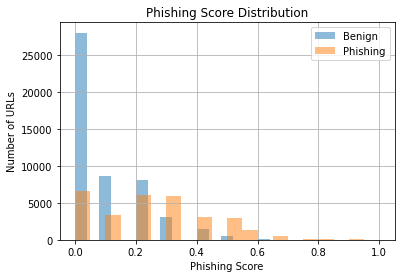

In [24]:
from sklearn.metrics import confusion_matrix, classification_report

# Apply scoring
df["score"] = df["url"].apply(is_phishing_url)
df["predicted"] = (df["score"] > 0.3).astype(int)

# Evaluation
y_true = df["label"]
y_pred = df["predicted"]

# Confusion Matrix: [ [TN, FP], [FN, TP] ]
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

# Coverage = True Positives / Total Phishing
coverage = tp / (tp + fn)

# Error Rate = False Positives / Total Benign
error_rate = fp / (fp + tn)

# Print classification summary
print("Confusion Matrix:\n", cm)
print(classification_report(y_true, y_pred))
print(f"✅ Coverage (TPR): {coverage:.4f}")
print(f"❌ Error Rate (FPR): {error_rate:.4f}")

# Plot score distribution
plt.hist(df[df["label"] == 0]["score"], bins=20, alpha=0.5, label='Benign')
plt.hist(df[df["label"] == 1]["score"], bins=20, alpha=0.5, label='Phishing')
plt.legend()
plt.xlabel("Phishing Score")
plt.ylabel("Number of URLs")
plt.title("Phishing Score Distribution")
plt.grid(True)
plt.show()


Not too bad. Maybe we can improve it by choosing the best threshold:

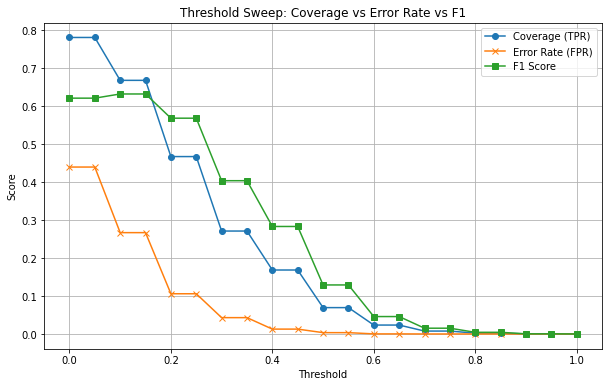

In [16]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.0, 1.01, 0.05)
tpr_list = []
fpr_list = []
f1_list = []

y_true = df["label"]
scores = df["score"]

for threshold in thresholds:
    y_pred = (scores > threshold).astype(int)
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    tn = ((y_pred == 0) & (y_true == 0)).sum()

    tpr = tp / (tp + fn) if (tp + fn) else 0
    fpr = fp / (fp + tn) if (fp + tn) else 0
    f1 = f1_score(y_true, y_pred)

    tpr_list.append(tpr)
    fpr_list.append(fpr)
    f1_list.append(f1)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(thresholds, tpr_list, label='Coverage (TPR)', marker='o')
plt.plot(thresholds, fpr_list, label='Error Rate (FPR)', marker='x')
plt.plot(thresholds, f1_list, label='F1 Score', marker='s')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Sweep: Coverage vs Error Rate vs F1")
plt.legend()
plt.grid(True)
plt.show()


### Let's try an ML-based solution for URL based detection: 
#### Let's start with a decision tree

In [6]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter
from urllib.parse import urlparse
import math
import re

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the phishing dataset
df = pd.read_csv("datasets/mendeley/phishing_dataset_mendeley.csv")  # Make sure this file exists in your working directory

train_df, val_df = train_test_split(
    df, test_size=0.1, random_state=42, stratify=df["label"]
)

# Save to CSV
train_df.to_csv("datasets/mendeley/train_urls.csv", index=False)
val_df.to_csv("datasets/mendeley/val_urls.csv", index=False)

print("✅ Split completed:")
print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")

# print how many phishing and benign URLs are in the training set
print("Training set:")
print(train_df["label"].value_counts())
print("Validation set:")
print(val_df["label"].value_counts())


✅ Split completed:
Train size: 71988
Validation size: 7999
Training set:
label
0    44991
1    26997
Name: count, dtype: int64
Validation set:
label
0    4999
1    3000
Name: count, dtype: int64


#### First, we'll need to extract the features

In [8]:

# 1. Feature Extractor
def entropy(s):
    probs = [freq / len(s) for freq in Counter(s).values()]
    return -sum(p * math.log2(p) for p in probs)

def extract_url_features(url):
    try:
        parsed = urlparse(url)
        hostname = parsed.hostname or ""
        tld = hostname.split('.')[-1] if '.' in hostname else ''
        subdomain = '.'.join(hostname.split('.')[:-2]) if len(hostname.split('.')) >= 3 else ''
        query = parsed.query or ''
        path = parsed.path or ''

        features = {
            "url_length": len(url),
            "hostname_length": len(hostname),
            "subdomain_length": len(subdomain),
            "num_digits": sum(c.isdigit() for c in hostname),
            "num_hyphens": hostname.count('-'),
            "num_tokens": len(hostname.split('.')),
            "num_slashes": url.count('/'),
            "has_at_symbol": int('@' in url),
            "has_ip_address": int(re.match(r'^\d{1,3}(\.\d{1,3}){3}$', hostname) is not None),
            "is_free_hosting": int(any(fh in hostname for fh in ["weebly", "netlify", "000webhost", "github"])),
            "has_suspicious_port": int(parsed.port not in [None, 80, 443]),
            "has_exe_or_zip": int(bool(re.search(r'\.(exe|zip|rar)$', url.lower()))),
            "has_long_query": int(len(query) > 50),
            "has_keywords": int(any(k in url.lower() for k in ["login", "verify", "account", "secure", "update", "bank"])),
            "has_suspicious_tld": int(tld in ["tk", "ml", "ga", "cf", "gq"]),
            "high_entropy_domain": int(entropy(hostname) > 4.3),
        }
        return features
    except:
        return {k: 0 for k in [
            "url_length", "hostname_length", "subdomain_length", "num_digits", "num_hyphens",
            "num_tokens", "num_slashes", "has_at_symbol", "has_ip_address", "is_free_hosting",
            "has_suspicious_port", "has_exe_or_zip", "has_long_query", "has_keywords",
            "has_suspicious_tld", "high_entropy_domain"
        ]}

#### Here we have our full training + eval pipline. 
- In addition, we experiment with another set of features: "extract_url_features_v2() and extract_url_features_v3()"

In [9]:
import pandas as pd
import numpy as np
import re
from urllib.parse import urlparse
from collections import Counter
import math
from itertools import product
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import confusion_matrix, f1_score, classification_report, precision_recall_curve

import Levenshtein

TOP_DOMAINS = [
    "google.com","bing.com","yahoo.com","duckduckgo.com","yandex.ru","baidu.com",
    "facebook.com","instagram.com","x.com","twitter.com","whatsapp.com","reddit.com",
    "youtube.com","netflix.com","tiktok.com","twitch.tv",
    "amazon.com","ebay.com","paypal.com","aliexpress.com","etsy.com",
    "apple.com","microsoft.com","office.com","live.com","github.com",
    "stackoverflow.com","cloudflare.com","openai.com","chatgpt.com",
    "wikipedia.org","nytimes.com","bbc.com","weather.com",
    "linkedin.com","indeed.com",
    "spotify.com","canva.com","pinterest.com",
    "roblox.com","zoom.us","imdb.com","fandom.com",
    "gmail.com","mail.yahoo.com","outlook.com"
]


# ---------------------- Function 1: Feature Extractor ----------------------
def entropy(s):
    """Calculate the Shannon entropy of a string."""
    probs = [freq / len(s) for freq in Counter(s).values()]
    return -sum(p * math.log2(p) for p in probs)

def _is_subdomain_of(host, parent):
    return host==parent or host.endswith("."+parent)

def extract_url_features_v2(url):
    """
    Enhanced feature extractor for URLs.
    Returns a dictionary of features including base structural measures,
    lexical elements, and newly added features.
    """
    try:
        parsed = urlparse(url)
        hostname = parsed.hostname or ""
        tld = hostname.split('.')[-1] if '.' in hostname else ''
        subdomain = '.'.join(hostname.split('.')[:-2]) if len(hostname.split('.')) >= 3 else ''
        query = parsed.query or ''
        path = parsed.path or ''
        query_params = query.split('&') if query else []

        # For path-based features:
        path_keywords = ["reset", "secure", "auth", "confirm"]
        suspicious_extensions = [".php", ".asp", ".cgi", ".jsp", ".exe"]

        features = {
            # Base continuous features
            "url_length": len(url),
            "hostname_length": len(hostname),
            "subdomain_length": len(subdomain),
            "num_digits": sum(c.isdigit() for c in hostname),
            "num_hyphens": hostname.count('-'),
            "num_tokens": len(hostname.split('.')),
            "num_slashes": url.count('/'),
            # Base binary features
            "has_at_symbol": int('@' in url),
            "has_ip_address": int(re.match(r'^\d{1,3}(\.\d{1,3}){3}$', hostname) is not None),
            "is_free_hosting": int(any(fh in hostname for fh in ["weebly", "netlify", "000webhost", "github"])),
            "has_suspicious_port": int(parsed.port not in [None, 80, 443]),
            "has_exe_or_zip": int(bool(re.search(r'\.(exe|zip|rar)$', url.lower()))),
            "has_long_query": int(len(query) > 50),
            "has_keywords": int(any(k in url.lower() for k in ["login", "verify", "account", "secure", "update", "bank"])),
            "has_suspicious_tld": int(tld in ["tk", "ml", "ga", "cf", "gq"]),
            "high_entropy_domain": int(entropy(hostname) > 4.3),
            # New features
            "is_numeric_domain": int(re.match(r'^\d+$', hostname.replace('.', '').replace('-', '')) is not None),
            "domain_ends_with_number": int(re.search(r'\d$', hostname.split('.')[-2]) is not None) if len(hostname.split('.')) >= 2 else 0,
            "path_contains_keywords": int(any(k in path.lower() for k in path_keywords)),
            "filename_suspicious_ext": int(any(path.lower().endswith(ext) for ext in suspicious_extensions)),
            "num_query_params": len(query_params)
        }
        return features
    except Exception as e:
        # In case of error, return zeros for all defined features.
        keys = [
            "url_length", "hostname_length", "subdomain_length", "num_digits", "num_hyphens",
            "num_tokens", "num_slashes", "has_at_symbol", "has_ip_address", "is_free_hosting",
            "has_suspicious_port", "has_exe_or_zip", "has_long_query", "has_keywords",
            "has_suspicious_tld", "high_entropy_domain", "is_numeric_domain",
            "domain_ends_with_number", "path_contains_keywords", "filename_suspicious_ext", "num_query_params"
        ]
        return {key: 0 for key in keys}


def extract_url_features_v3(url):
    try:
        parsed = urlparse(url)
        hostname = parsed.hostname or "".lower()
        tld = hostname.split('.')[-1] if '.' in hostname else ''
        subdomain = '.'.join(hostname.split('.')[:-2]) if len(hostname.split('.')) >= 3 else ''
        query = parsed.query or ''
        path = parsed.path or ''
        query_params = query.split('&') if query else []

        # Keyword checks and suspicious extensions for path.
        path_keywords = ["reset", "secure", "auth", "confirm"]
        suspicious_extensions = [".php", ".asp", ".cgi", ".jsp", ".exe"]

        features = {
            "url_length": len(url),
            "hostname_length": len(hostname),
            "subdomain_length": len(subdomain),
            "num_digits": sum(c.isdigit() for c in hostname),
            "num_hyphens": hostname.count('-'),
            "num_tokens": len(hostname.split('.')),
            "num_slashes": url.count('/'),
            "has_at_symbol": int('@' in url),
            "has_ip_address": int(re.fullmatch(r'^\d{1,3}(?:\.\d{1,3}){3}$', hostname) is not None),
            "is_free_hosting": int(any(fh in hostname for fh in ["weebly", "netlify", "000webhost", "github"])),
            "has_suspicious_port": int(parsed.port not in [None, 80, 443]),
            "has_exe_or_zip": int(bool(re.search(r'\.(exe|zip|rar)$', url.lower()))),
            "has_long_query": int(len(query) > 50),
            "has_keywords": int(any(k in url.lower() for k in ["login", "verify", "account", "secure", "update", "bank"])),
            "has_suspicious_tld": int(tld in ["tk", "ml", "ga", "cf", "gq"]),
            "high_entropy_domain": int(entropy(hostname) > 4.3),
            
            # Additional static features.
            "is_numeric_domain": int(re.fullmatch(r'^\d+$', hostname.replace('.', '').replace('-', '')) is not None),
            "domain_ends_with_number": int(re.search(r'\d$', hostname.split('.')[-2]) is not None) if len(hostname.split('.')) > 1 else 0,
            "path_contains_keywords": int(any(k in path.lower() for k in path_keywords)),
            "filename_suspicious_ext": int(any(path.lower().endswith(ext) for ext in suspicious_extensions)),
            "num_query_params": len(query_params)
        }
        
        # Extra features based on research.
        features["repeated_chars"] = int(bool(re.search(r'(.)\1{4,}', hostname)))
        features["is_punycode"] = int("xn--" in hostname)
        features["excess_subdomains"] = int(hostname.count('.') > 3)
        shorteners = ["bit.ly", "tinyurl.com", "goo.gl", "ow.ly", "t.co"]
        features["url_shortener"] = int(any(shortener in url for shortener in shorteners))
        features["non_https"] = int(parsed.scheme.lower() != "https")
        
        popular_domains = ["google.com", "paypal.com", "facebook.com", "amazon.com", "apple.com"]
        if popular_domains:
            distances = [Levenshtein.distance(hostname, pd) for pd in popular_domains]
            min_distance = min(distances)
        else:
            min_distance = float('inf')
        features["levenshtein_flag"] = int(min_distance <= 2)
        
        # Additional entropy and ratio features.
        features["path_entropy"] = entropy(path)
        features["query_entropy"] = entropy(query)
        features["ratio_digits_hostname"] = sum(c.isdigit() for c in hostname) / len(hostname) if hostname else 0
        special_chars_count = sum(1 for c in hostname if not c.isalnum() and c not in ".-")
        features["ratio_special_chars_hostname"] = special_chars_count / len(hostname) if hostname else 0
        tokens = hostname.split('.')
        features["unique_token_ratio"] = len(set(tokens)) / len(tokens) if tokens else 0
        features["has_many_subdirectories"] = int(path.count('/') > 3)
        features["contains_encoded_chars"] = int('%' in url)
        features["num_query_equals"] = query.count('=') if query else 0

        is_top = any(_is_subdomain_of(hostname, dom) for dom in TOP_DOMAINS)
        is_exact = hostname in TOP_DOMAINS
        features["is_top_domain"] = int(is_top)
        features["is_exact_top_domain"] = int(is_exact)
        return features
    
    except Exception as e:
        print("Error extracting features:", e)
        keys = [
            "url_length", "hostname_length", "subdomain_length", "num_digits", "num_hyphens",
            "num_tokens", "num_slashes", "has_at_symbol", "has_ip_address", "is_free_hosting",
            "has_suspicious_port", "has_exe_or_zip", "has_long_query", "has_keywords",
            "has_suspicious_tld", "high_entropy_domain", "is_numeric_domain",
            "domain_ends_with_number", "path_contains_keywords", "filename_suspicious_ext", "num_query_params",
            "repeated_chars", "is_punycode", "excess_subdomains", "url_shortener", "non_https", "levenshtein_flag",
            "path_entropy", "query_entropy", "ratio_digits_hostname", "ratio_special_chars_hostname",
            "unique_token_ratio", "has_many_subdirectories", "contains_encoded_chars", "num_query_equals"
        ]
        return {k: 0 for k in keys}
    
    
# ---------------------- Function 2: Feature Extraction from DataFrame ----------------------
def extract_features_from_df(df, extract_url_features_func):
    """
    Given a DataFrame with a "url" column and a label column ("label"),
    extracts features using the provided function and returns X, y.
    """
    X = df["url"].apply(extract_url_features_func).apply(pd.Series)
    y = df["label"]
    return X, y

# ---------------------- Function 3: Hyperparameter Tuning ----------------------
def grid_search_tuning(X_train, y_train, X_val, y_val, param_grid):
    """
    Perform grid search over the hyperparameters for DecisionTreeClassifier.
    Returns a sorted DataFrame of results (sorted by F1 score descending).
    """
    results = []
    for max_depth, min_samples_leaf, criterion in product(*param_grid.values()):
        model = DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            criterion=criterion,
            random_state=42
        )
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        cm = confusion_matrix(y_val, y_pred)
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
        else:
            tn = fp = fn = tp = 0
        tpr = tp / (tp + fn) if (tp + fn) else 0  # Coverage (Recall for phishing)
        fpr = fp / (fp + tn) if (fp + tn) else 0  # Error rate
        f1 = f1_score(y_val, y_pred)
        results.append({
            "max_depth": max_depth,
            "min_samples_leaf": min_samples_leaf,
            "criterion": criterion,
            "F1": round(f1, 4),
            "TPR (Coverage)": round(tpr, 4),
            "FPR (Error Rate)": round(fpr, 4)
        })
    results_df = pd.DataFrame(results)
    results_df_sorted = results_df.sort_values(by="F1", ascending=False)
    return results_df_sorted

# ---------------------- Function 4: Plotting Grid Search Results ----------------------
def plot_grid_search_results(results_df):
    """
    Plots a scatter plot of TPR vs. FPR for the grid search tuning, colored by F1 score.
    """
    plt.figure(figsize=(8, 5))
    sc = plt.scatter(results_df["FPR (Error Rate)"], results_df["TPR (Coverage)"],
                     c=results_df["F1"], cmap='viridis', s=100)
    plt.colorbar(sc, label="F1 Score")
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR / Coverage)")
    plt.title("Hyperparameter Tuning: TPR vs FPR (Colored by F1 Score)")
    plt.grid(True)
    plt.show()

# ---------------------- Function 5: Train the Final Model ----------------------
def train_final_model(X_train, y_train, best_config):
    """
    Trains and returns a DecisionTreeClassifier using the best hyperparameter configuration.
    """
    model = DecisionTreeClassifier(
        max_depth=int(best_config["max_depth"]),
        min_samples_leaf=int(best_config["min_samples_leaf"]),
        criterion=best_config["criterion"],
        random_state=42
    )
    model.fit(X_train, y_train)
    return model

# Evaluate a model on validation data and optionally plot decision tree and feature importances
def evaluate_model(model, X_val, y_val, plot_tree_flag=False):
    y_pred = model.predict(X_val)
    cm = confusion_matrix(y_val, y_pred)
    report = classification_report(y_val, y_pred, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    
    print("📊 Confusion Matrix:\n", cm)
    print("\n📋 Classification Report:\n", report_df)
    
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        coverage = tp / (tp + fn) if (tp + fn) else 0
        error_rate = fp / (fp + tn) if (fp + tn) else 0
    else:
        coverage = error_rate = 0
    print(f"✅ Final Coverage (TPR): {coverage:.4f}")
    print(f"❌ Final Error Rate (FPR): {error_rate:.4f}")
    
    if plot_tree_flag:
        plt.figure(figsize=(12, 8))
        plot_tree(model, feature_names=list(X_val.columns), filled=True, rounded=True)
        plt.title("Decision Tree Visualization")
        plt.show()
        
    # Plot feature importances
    feature_names = list(X_val.columns)
    importances = model.feature_importances_
    sorted_idx = np.argsort(importances)[::-1]
    sorted_names = [feature_names[i] for i in sorted_idx]
    sorted_importances = importances[sorted_idx]
    
    plt.figure(figsize=(10, 6))
    plt.barh(sorted_names[::-1], sorted_importances[::-1])
    plt.xlabel("Feature Importance")
    plt.title("Feature Importance of Decision Tree")
    plt.tight_layout()
    plt.grid(True)
    plt.show()

# ---------------------- Function 7: Full Pipeline Wrapper ----------------------
def run_pipeline_full(train_df, validation_dataframes: list, param_grid, extract_url_features_func, plot_tree_flag=False):
    """
    Full pipeline that:
      1. Extracts features using a provided extractor function.
      2. Performs hyperparameter tuning (grid search) for Decision Tree.
      3. Plots grid search results.
      4. Trains a final model using the best configuration.
      5. Evaluates the final model and optionally visualizes the decision tree and feature importances.
    
    Returns: best_model, best_config, tuning_results (sorted DataFrame).
    """
    # Step 1: Feature Extraction
    X_train, y_train = extract_features_from_df(train_df, extract_url_features_func)
    # Extract features from all validation dataframes
    X_val_list, y_val_list = [], []
    for val_df in validation_dataframes:
        X_val_temp, y_val_temp = extract_features_from_df(val_df, extract_url_features_func)
        X_val_list.append(X_val_temp)
        y_val_list.append(y_val_temp)
    
    # Step 2: Hyperparameter Tuning (Grid Search)
    tuning_results = grid_search_tuning(X_train, y_train, X_val_list[0], y_val_list[0], param_grid)
    plot_grid_search_results(tuning_results)
    
    # Step 3: Select and show the best configuration
    print("🔝 Top 5 Configurations by F1 Score:")
    print(tuning_results.head())
    best_config = tuning_results.iloc[0]
    print("\n✅ Best Configuration by F1 Score:")
    print(best_config)
    
    # Step 4: Train final model with best configuration
    best_model = train_final_model(X_train, y_train, best_config)
    
    # Step 5: Evaluate final model
    for i, (X_val, y_val) in enumerate(zip(X_val_list, y_val_list)):
        print(f"\n🔍 Evaluation on Validation Set {i+1}:")
        evaluate_model(best_model, X_val, y_val, plot_tree_flag)
    
    # Optionally, print textual representation of the tree
    if plot_tree_flag:
        print("\n📝 Decision Tree Rules:")
        tree_rules = export_text(best_model, feature_names=list(X_train.columns))
        print(tree_rules)
    
    return best_model, best_config, tuning_results


### v1

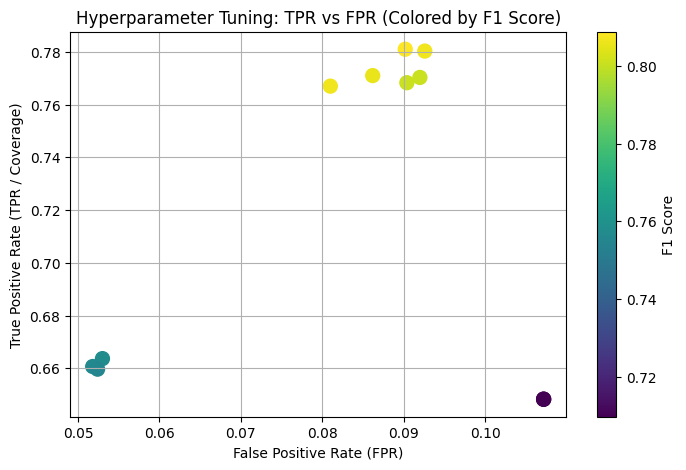

🔝 Top 5 Configurations by F1 Score:
    max_depth  min_samples_leaf criterion      F1  TPR (Coverage)  \
9          30                 5      gini  0.8088          0.7810   
10         30                10      gini  0.8067          0.7803   
6          20                 5      gini  0.8065          0.7670   
7          20                10      gini  0.8054          0.7710   
11         30                20      gini  0.8009          0.7703   

    FPR (Error Rate)  
9             0.0902  
10            0.0926  
6             0.0810  
7             0.0862  
11            0.0920  

✅ Best Configuration by F1 Score:
max_depth               30
min_samples_leaf         5
criterion             gini
F1                  0.8088
TPR (Coverage)       0.781
FPR (Error Rate)    0.0902
Name: 9, dtype: object

🔍 Evaluation on Validation Set 1:
📊 Confusion Matrix:
 [[4548  451]
 [ 657 2343]]

📋 Classification Report:
               precision    recall  f1-score      support
0              0.873775 

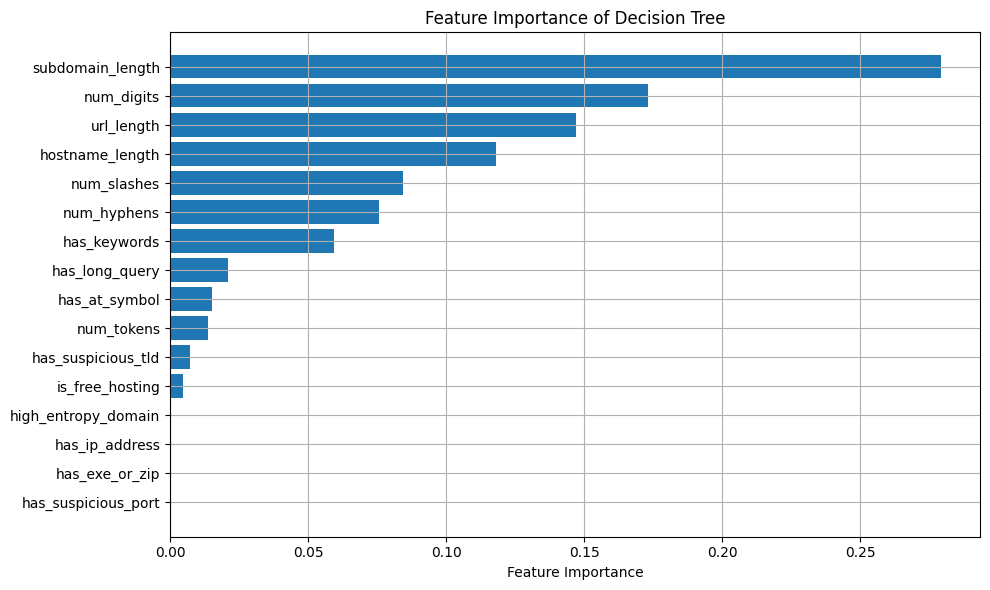

In [10]:

# Define the hyperparameter grid
param_grid = {
    "max_depth": [5, 10, 20, 30],
    "min_samples_leaf": [5, 10, 20],
    "criterion": ["gini"]
}

# Run the pipeline; adjust file paths as needed
best_model, best_config, tuning_results = run_pipeline_full(train_df, [val_df], param_grid, extract_url_features)

### v2

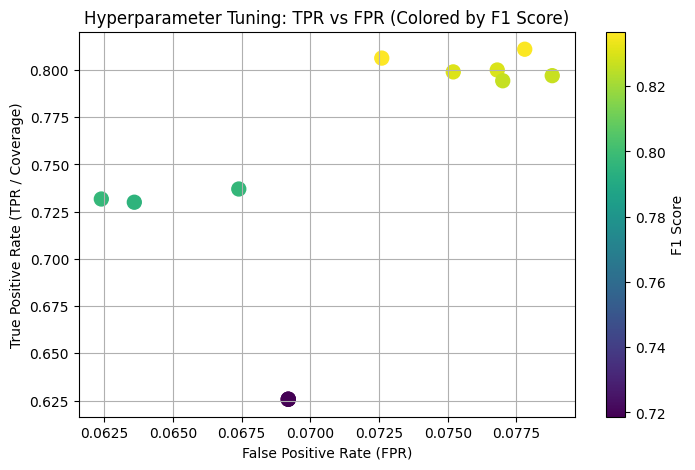

🔝 Top 5 Configurations by F1 Score:
    max_depth  min_samples_leaf criterion      F1  TPR (Coverage)  \
6          20                 5      gini  0.8367          0.8063   
9          30                 5      gini  0.8358          0.8110   
7          20                10      gini  0.8304          0.7990   
10         30                10      gini  0.8299          0.8000   
11         30                20      gini  0.8266          0.7970   

    FPR (Error Rate)  
6             0.0726  
9             0.0778  
7             0.0752  
10            0.0768  
11            0.0788  

✅ Best Configuration by F1 Score:
max_depth               20
min_samples_leaf         5
criterion             gini
F1                  0.8367
TPR (Coverage)      0.8063
FPR (Error Rate)    0.0726
Name: 6, dtype: object

🔍 Evaluation on Validation Set 1:
📊 Confusion Matrix:
 [[4636  363]
 [ 581 2419]]

📋 Classification Report:
               precision    recall  f1-score      support
0              0.888633 

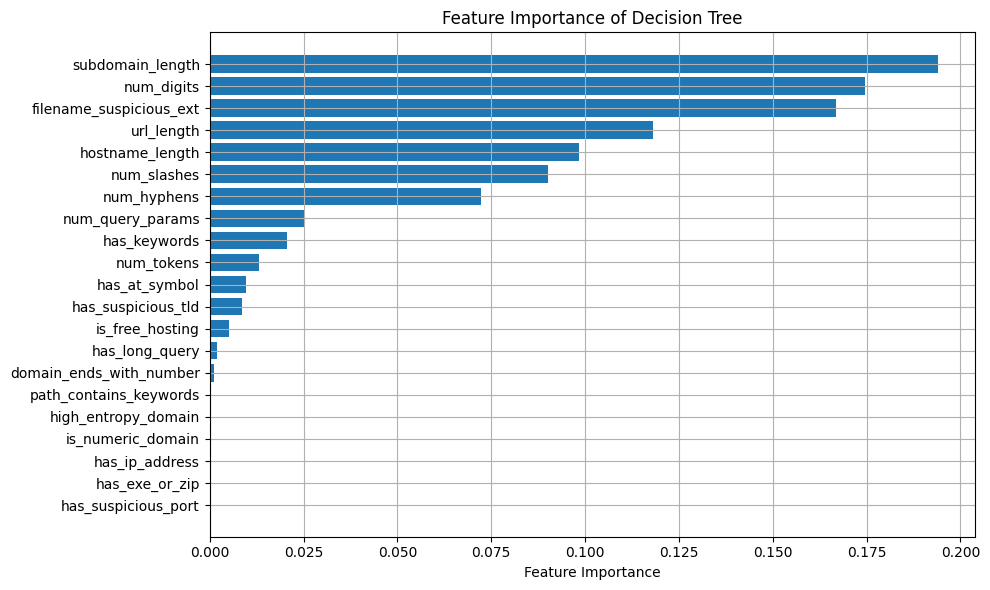

In [11]:
# Define the hyperparameter grid
param_grid = {
    "max_depth": [5, 10, 20, 30],
    "min_samples_leaf": [5, 10, 20],
    "criterion": ["gini"]
}

# Run the pipeline; adjust file paths as needed
best_model, best_config, tuning_results = run_pipeline_full(train_df, [val_df], param_grid, extract_url_features_v2)

### v3

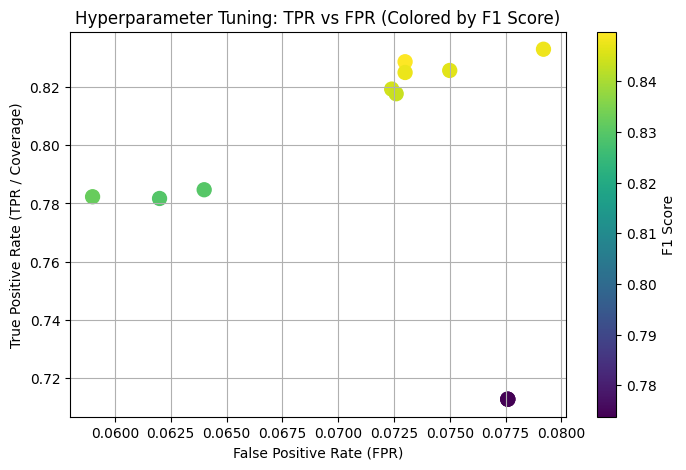

🔝 Top 5 Configurations by F1 Score:
    max_depth  min_samples_leaf criterion      F1  TPR (Coverage)  \
6          20                 5      gini  0.8498          0.8287   
9          30                 5      gini  0.8478          0.8330   
7          20                10      gini  0.8476          0.8250   
10         30                10      gini  0.8465          0.8257   
8          20                20      gini  0.8447          0.8193   

    FPR (Error Rate)  
6             0.0730  
9             0.0792  
7             0.0730  
10            0.0750  
8             0.0724  

✅ Best Configuration by F1 Score:
max_depth               20
min_samples_leaf         5
criterion             gini
F1                  0.8498
TPR (Coverage)      0.8287
FPR (Error Rate)     0.073
Name: 6, dtype: object

🔍 Evaluation on Validation Set 1:
📊 Confusion Matrix:
 [[4634  365]
 [ 514 2486]]

📋 Classification Report:
               precision    recall  f1-score      support
0              0.900155 

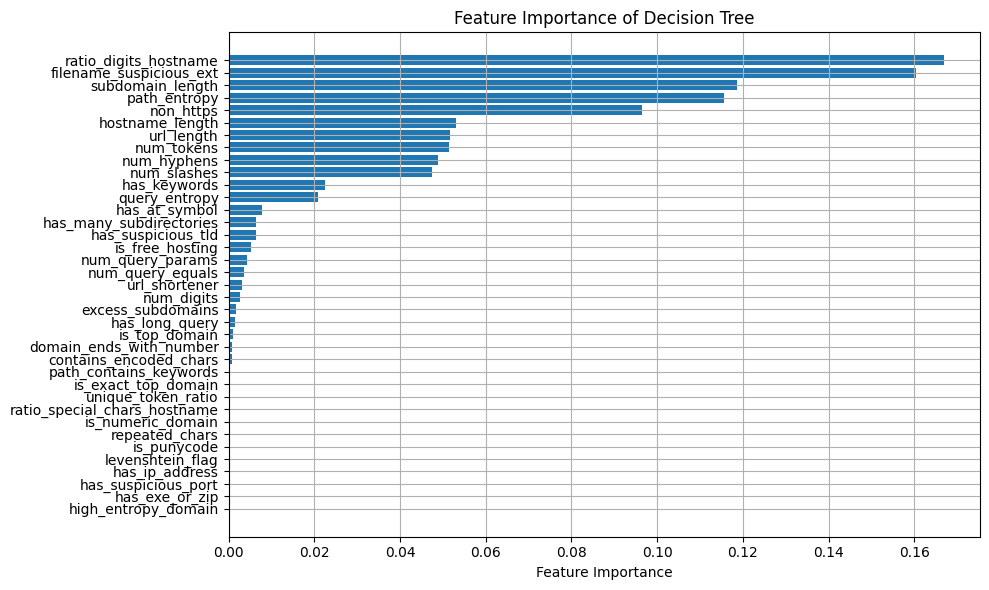

In [12]:
# Define the hyperparameter grid
param_grid = {
    "max_depth": [5, 10, 20, 30],
    "min_samples_leaf": [5, 10, 20],
    "criterion": ["gini"]
}

# Run the pipeline; adjust file paths as needed
best_model, best_config, tuning_results = run_pipeline_full(train_df, [val_df], param_grid, extract_url_features_v3)

Seems that v3 reaches the best results :)

### Now let's try XGBoost

In [ ]:
# ===============================================================
#      OFF-LINE  EVALUATION  OF  THE  SAVED  URL  MODEL
#      dataset csv must have columns: rec_id , url , label (1=phish,0=benign)
# ===============================================================
import json, time, sys, os, psutil, xgboost as xgb, pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve
import pandas as pd

# ─── 0. paths ────────────────────────────────────────────────────
ART_DIR   = Path("model_artifacts_url")      # folder created earlier
TEST_CSV  = "val_urls.csv"  # path to your csv

# ─── 1. load model + meta ───────────────────────────────────────
booster = xgb.Booster()
booster.load_model(ART_DIR / "url_xgb.json")

feature_order = json.load(open(ART_DIR / "url_features.json"))
thr           = float(open(ART_DIR / "url_threshold.txt").read().strip())

# memory footprint (model json + meta) in KB
model_bytes = (ART_DIR / "url_xgb.json").stat().st_size \
            + (ART_DIR / "url_features.json").stat().st_size
print(f"Model files: {model_bytes/1024:.1f} KB")


# ─── 3. load dataset & build matrix ─────────────────────────────
df = pd.read_csv(TEST_CSV)

X_list = []
for u in df["url"]:
    fd = extract_url_features_v3(u)                     # dict
    row = [fd.get(k, 0.0) for k in feature_order]       # list in saved order
    X_list.append(row)

X_mat = np.asarray(X_list, dtype=np.float32)
dtest  = xgb.DMatrix(X_mat, feature_names=feature_order)
y_true = df["label"].values

# ─── 4. inference & timing ─────────────────────────────────────
t0 = time.perf_counter()
proba = booster.predict(dtest)
latency_ms = (time.perf_counter() - t0)/len(df)*1000
pred  = (proba >= thr).astype(int)

# ─── 5. metrics  ────────────────────────────────────────────────
cm = confusion_matrix(y_true, pred, labels=[0,1])  # [[TN FP][FN TP]]
tn, fp, fn, tp = cm.ravel()
coverage      = tp / (tp+fn) if (tp+fn) else 0     # recall of phishing
error_rate    = fp / (fp+tn) if (fp+tn) else 0     # FPR
precision     = tp / (tp+fp) if (tp+fp) else 0
f1            = 2*precision*coverage/(precision+coverage+1e-9)


# put every URL into a decile based on predicted proba
bins   = np.linspace(0, 1, 11)          # 0-0.1, 0.1-0.2, … 0.9-1.0
labels = [f"{int(b*100)}–{int((b+0.1)*100)}%" for b in bins[:-1]]
bucket = pd.cut(proba, bins=bins, labels=labels, include_lowest=True)

# dataframe to aggregate
df_eval = pd.DataFrame({
    "bucket": bucket,
    "truth" : y_true,
    "pred"  : pred
})

g = df_eval.groupby("bucket", observed=True)

# individual aggregates
total  = g.size()
errors = g.apply(lambda d: (d.truth != d.pred).sum())
fp     = g.apply(lambda d: ((d.truth == 0) & (d.pred == 1)).sum())
fn     = g.apply(lambda d: ((d.truth == 1) & (d.pred == 0)).sum())

# assemble tidy table
err_tbl = pd.DataFrame({
    "total" : total,
    "errors": errors,
    "FP"    : fp,
    "FN"    : fn
}).fillna(0).astype(int)

# add percentages
err_tbl["error_rate%"] = (err_tbl.errors / err_tbl.total * 100).round(1)
err_tbl["FP_rate%"]    = (err_tbl.FP     / err_tbl.total * 100).round(1)
err_tbl["FN_rate%"]    = (err_tbl.FN     / err_tbl.total * 100).round(1)

print("\nError distribution by predicted phishing probability (deciles):")
print(err_tbl[["total","errors","error_rate%","FP_rate%","FN_rate%"]].to_string())

print("\nConfusion matrix [[TN FP][FN TP]]:\n", cm)
print(classification_report(y_true, pred, digits=3))
print(f"Coverage (TPR)       : {coverage:.3f}")
print(f"Error rate  (FPR)    : {error_rate:.3f}")
print(f"Precision            : {precision:.3f}")
print(f"F1 score             : {f1:.3f}")
print(f"Avg latency / URL    : {latency_ms:.2f} ms")
print(f"RAM after load (MB)  : {psutil.Process(os.getpid()).memory_info().rss/1024/1024:.1f}")


Model files: 4501.3 KB

Error distribution by predicted phishing probability (deciles):
         total  errors  error_rate%  FP_rate%  FN_rate%
bucket                                                 
0–10%     4108      22          0.5       0.0       0.5
10–20%     402      30          7.5       0.0       7.5
20–30%     337      62         18.4       0.0      18.4
30–40%     150      50         33.3       0.0      33.3
40–50%     121      46         38.0      33.1       5.0
50–60%     113      42         37.2      37.2       0.0
60–70%     127      30         23.6      23.6       0.0
70–80%     152      24         15.8      15.8       0.0
80–90%     245       9          3.7       3.7       0.0
90–100%   2244       4          0.2       0.2       0.0

Confusion matrix [[TN FP][FN TP]]:
 [[4850  149]
 [ 170 2830]]
              precision    recall  f1-score   support

           0      0.966     0.970     0.968      4999
           1      0.950     0.943     0.947      3000

    accuracy

/var/folders/qc/67jplx2s3fjbl7wv0d3cqrrr0000gn/T/ipykernel_97157/2343610521.py:173: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  errors = g.apply(lambda d: (d.truth != d.pred).sum())
/var/folders/qc/67jplx2s3fjbl7wv0d3cqrrr0000gn/T/ipykernel_97157/2343610521.py:174: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fp     = g.apply(lambda d: ((d.truth == 0) & (d.pred == 1)).sum())
/var/folders/qc/67jplx2s3fjbl

In [ ]:
# ─── 6. eval low & high-confidence subsets ────────────────────────
# Define your two slices:
mask_high = proba >= 0.85
mask_low  = proba <= 0.2

def subset_stats(mask):
    size   = int(mask.sum())
    phish  = int(((y_true == 1) & mask).sum())
    benign = int(((y_true == 0) & mask).sum())
    if size:
        phish_rate  = phish  / size * 100
        benign_rate = benign / size * 100
    else:
        phish_rate = benign_rate = 0.0
    return size, phish_rate, benign_rate

h_count, h_prate, h_brate = subset_stats(mask_high)
l_count, l_prate, l_brate = subset_stats(mask_low)

print("\nHigh-confidence (proba ≥ 0.90):")
print(f"  count = {h_count} URLs")
print(f"  phishing rate = {h_prate:.1f}%")
print(f"  benign    rate = {h_brate:.1f}%")

print("\nLow-confidence  (proba ≤ 0.10):")
print(f"  count = {l_count} URLs")
print(f"  phishing rate = {l_prate:.1f}%")
print(f"  benign    rate = {l_brate:.1f}%")



High-confidence (proba ≥ 0.90):
  count = 2377 URLs
  phishing rate = 99.7%
  benign    rate = 0.3%

Low-confidence  (proba ≤ 0.10):
  count = 4510 URLs
  phishing rate = 1.2%
  benign    rate = 98.8%


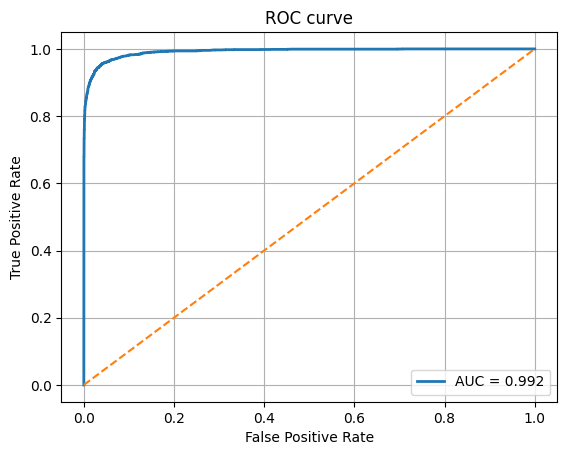

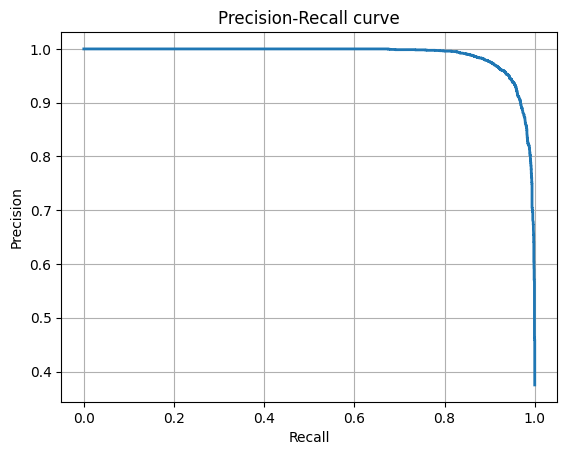

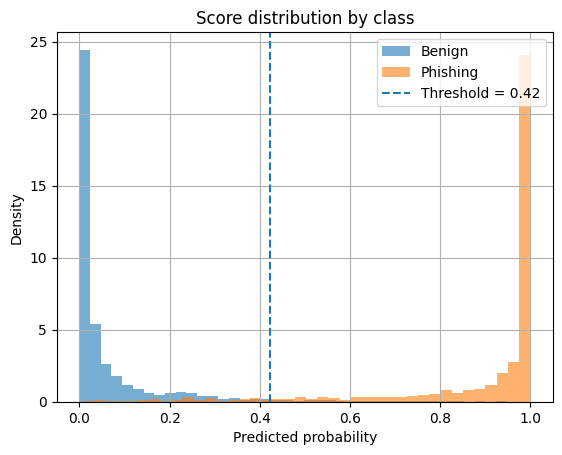

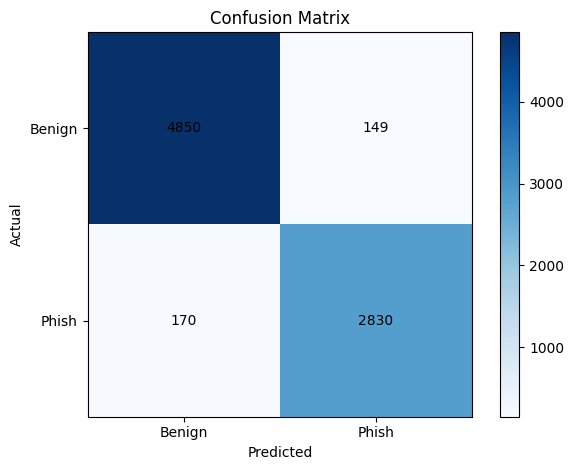

In [ ]:
# ===============================================================
#   VISUAL DIAGNOSTICS   – ROC, PR, Score-hist & Confusion Matrix
#   (requires variables: y_true , proba , thr , cm   from previous cell)
# ===============================================================
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve

# ---------- 1. ROC curve ----------
fpr, tpr, _ = roc_curve(y_true, proba)
roc_auc = roc_auc_score(y_true, proba)

plt.figure()
plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], ls="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")
plt.legend()
plt.grid(True)
plt.show()

# ---------- 2. Precision-Recall curve ----------
prec, reca, _ = precision_recall_curve(y_true, proba)
plt.figure()
plt.plot(reca, prec, lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve")
plt.grid(True)
plt.show()

# ---------- 3. Score distribution ----------
plt.figure()
plt.hist(proba[y_true == 0], bins=40, alpha=0.6, label="Benign", density=True)
plt.hist(proba[y_true == 1], bins=40, alpha=0.6, label="Phishing", density=True)
plt.axvline(thr, ls="--", label=f"Threshold = {thr:.2f}")
plt.xlabel("Predicted probability")
plt.ylabel("Density")
plt.title("Score distribution by class")
plt.legend()
plt.grid(True)
plt.show()

# ---------- 4. Confusion matrix heat-map ----------
plt.figure()
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Benign", "Phish"])
plt.yticks(tick_marks, ["Benign", "Phish"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, int(cm[i, j]), ha="center", va="center")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()


## Evaluate the hursitic URL based detection from the js:

In [ ]:
import psutil, time, os, math, re
from sklearn.metrics import confusion_matrix, classification_report

CSV_PATH = Path("val_urls.csv")          # your dataset
JS_CLI   = Path("score_url_cli.mjs")  

In [ ]:
df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df):,} URLs")
df.head()

Loaded 7,999 URLs


,rec_id,url,label
0,36769,https://indianabeach.com/,0
1,65427,https://cr.mufg.coolstart.co/pc/MUFG_pcselectc...,1
2,17313,https://www.impacteventsinc.com/,0
3,11248,http://thinkenglish.me/definition/latency-stag...,0
4,78946,https://www.authorization-newrequest.link/Logi...,1


In [ ]:
from tqdm.notebook import tqdm
import time, subprocess, re
import numpy as np

ANSI_RE = re.compile(r'\x1b\[[0-9;]*m')

def js_score(url: str) -> float:
    try:
        out = subprocess.check_output(
            ["node", str(JS_CLI), url],
            text=True, stderr=subprocess.DEVNULL
        )
        clean = ANSI_RE.sub("", out).strip()
        return float(clean)
    except Exception:
        return 0.0

# -----------------------------------------------------------------------------
scores = []
t0 = time.perf_counter()

for url in tqdm(df["url"], desc="Scoring URLs"):
    scores.append(js_score(url))

latency_ms = (time.perf_counter() - t0) / len(scores) * 1000
scores = np.array(scores, dtype=float)

print(f"Finished in {latency_ms:.2f} ms per URL (avg)")


Scoring URLs:   0%|          | 0/7999 [00:00<?, ?it/s]

Finished in 44.01 ms per URL (avg)


In [ ]:
THR = 30
pred  = (scores >= THR).astype(int)
y_true = df["label"].to_numpy(int)

cm = confusion_matrix(y_true, pred, labels=[0,1])
tn, fp, fn, tp = cm.ravel()
tpr = tp/(tp+fn) if tp+fn else 0
fpr = fp/(fp+tn) if fp+tn else 0
prec = tp/(tp+fp) if tp+fp else 0
f1   = 2*prec*tpr/(prec+tpr+1e-9)

print("Confusion matrix [[TN FP][FN TP]]")
print(cm)
print(classification_report(y_true, pred, digits=3))
print(f"TPR  : {tpr:.3f}")
print(f"FPR  : {fpr:.3f}")
print(f"Prec : {prec:.3f}")
print(f"F1   : {f1:.3f}")
print(f"RAM  : {psutil.Process(os.getpid()).memory_info().rss/1024/1024:.1f} MB")


Confusion matrix [[TN FP][FN TP]]
[[4983   16]
 [2595  405]]
              precision    recall  f1-score   support

           0      0.658     0.997     0.792      4999
           1      0.962     0.135     0.237      3000

    accuracy                          0.674      7999
   macro avg      0.810     0.566     0.515      7999
weighted avg      0.772     0.674     0.584      7999

TPR  : 0.135
FPR  : 0.003
Prec : 0.962
F1   : 0.237
RAM  : 82.1 MB


In [ ]:
import pandas as pd

# define your two masks
mask_low  = scores <= 0
mask_high = scores >= 31

def subset_metrics(mask, name):
    size = int(mask.sum())
    phish = int(((y_true == 1) & mask).sum())
    benign = size - phish
    return {
        "range": name,
        "count": size,
        "phish_rate (%)": round(phish/size*100, 1) if size else 0,
        "benign_rate (%)": round(benign/size*100, 1) if size else 0
    }

df_sub = pd.DataFrame([
    subset_metrics(mask_low,  "scores ≤ 5"),
    subset_metrics(mask_high, "scores ≥ 30")
])

df_sub


,range,count,phish_rate (%),benign_rate (%)
0,scores ≤ 5,3245,17.2,82.8
1,scores ≥ 30,675,92.6,7.4


In [ ]:
bins   = np.linspace(0, max(scores.max(),1), 11)
labels = [f"{int(b)}–{int(bins[1])}" for b in bins[:-1]]
bucket = pd.cut(scores, bins=bins, labels=labels, include_lowest=True)

tbl = (
    pd.DataFrame({"bucket":bucket,"truth":y_true,"pred":pred})
      .groupby("bucket", observed=True)
      .agg(total=('truth','size'),
           errors=(lambda d: (d.truth!=d.pred).sum()),
           FP =(lambda d: ((d.truth==0)&(d.pred==1)).sum()),
           FN =(lambda d: ((d.truth==1)&(d.pred==0)).sum()))
      .fillna(0).astype(int)
)
tbl["error_rate%"] = (tbl.errors / tbl.total * 100).round(1)
tbl["FP_rate%"]    = (tbl.FP     / tbl.total * 100).round(1)
tbl["FN_rate%"]    = (tbl.FN     / tbl.total * 100).round(1)

tbl


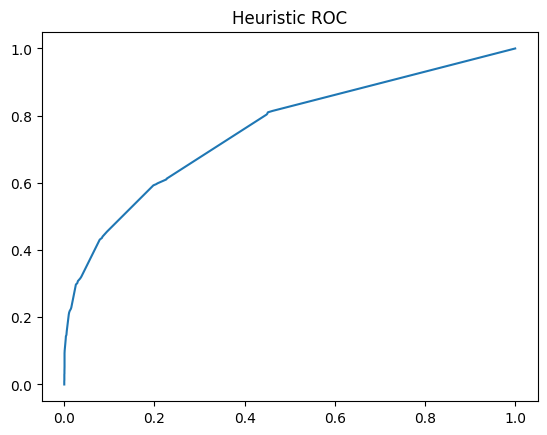

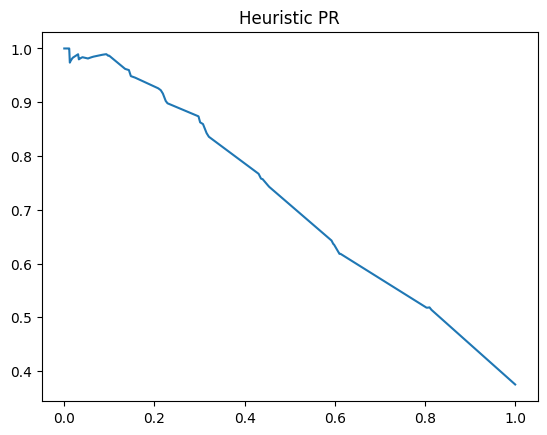

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_true, scores)
prec, reca, _ = precision_recall_curve(y_true, scores)

plt.figure(); plt.plot(fpr, tpr); plt.title("Heuristic ROC")
plt.figure(); plt.plot(reca, prec); plt.title("Heuristic PR")
plt.show()
